# 15 — Agent-based dynamics

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from optimizr import _core as opt
plt.rcParams['figure.figsize'] = (7, 4)
plt.rcParams['figure.dpi'] = 110


In [2]:
init = np.arange(40.0).tolist()
init_mean = float(np.mean(init))
res = opt.consensus_dynamics(init, alpha=0.3, noise_sigma=0.1,
                              n_steps=80, seed=0)
n_t = res['n_steps']; n_a = res['n_agents']
S = np.array(res['states_flat']).reshape(n_t, n_a)
mean_traj = np.array(res['mean_trajectory'])
print('initial mean =', init_mean)
print('final mean   =', mean_traj[-1])
print('final std    =', float(S[-1].std()))


initial mean = 19.5
final mean   = 19.44376167152161
final std    = 0.14305254923151872


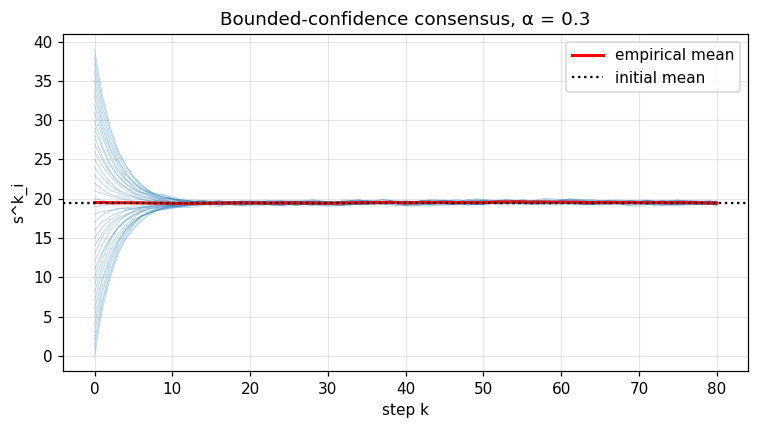

In [3]:
fig, ax = plt.subplots()
for i in range(n_a):
    ax.plot(S[:, i], color='tab:blue', alpha=0.3, lw=0.6)
ax.plot(mean_traj, color='red', lw=2, label='empirical mean')
ax.axhline(init_mean, color='k', ls=':', label='initial mean')
ax.set_xlabel('step k'); ax.set_ylabel('s^k_i'); ax.legend(); ax.grid(alpha=0.3)
ax.set_title('Bounded-confidence consensus, α = 0.3')
fig.tight_layout(); plt.show()


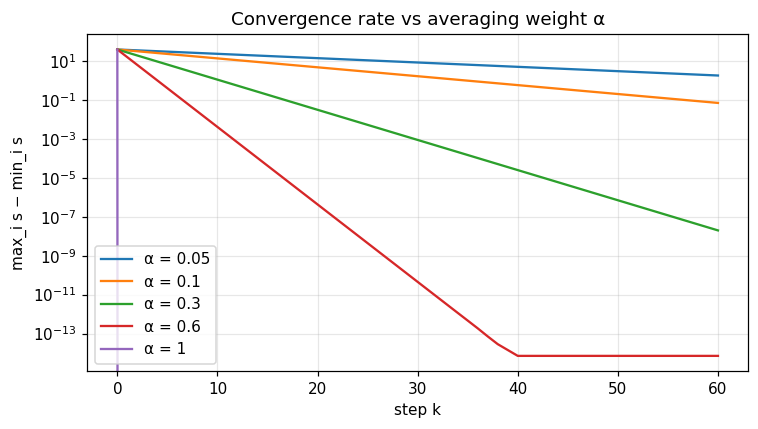

In [4]:
fig, ax = plt.subplots()
for alpha in [0.05, 0.1, 0.3, 0.6, 1.0]:
    r = opt.consensus_dynamics(init, alpha=alpha, noise_sigma=0.0, n_steps=60, seed=0)
    S = np.array(r['states_flat']).reshape(r['n_steps'], r['n_agents'])
    spread = S.max(axis=1) - S.min(axis=1)
    ax.semilogy(spread, label=f'α = {alpha:g}')
ax.set_xlabel('step k'); ax.set_ylabel('max_i s − min_i s')
ax.set_title('Convergence rate vs averaging weight α'); ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout(); plt.show()


**Verified:** without noise, the empirical mean is exactly preserved and the spread decays geometrically.